# Projeto 1 - ML: Análise Exploratória

**Autor:** Bernardo Nabais
**Dataset:** Airbnb Hong Kong (Inside Airbnb, junho-julho 2026)
**Objetivo:** justificar as decisões de pré-processamento aplicadas em `data_preparation.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/listings.csv", low_memory=False)
print(df.shape)

(6734, 90)


In [2]:
# Percentagem de missing por coluna
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing[missing > 0].round(1).head(20).to_string())

neighborhood_overview           100.0
host_since                      100.0
host_response_time              100.0
host_thumbnail_url              100.0
host_acceptance_rate            100.0
host_response_rate              100.0
host_verifications              100.0
neighbourhood                   100.0
host_total_listings_count       100.0
host_neighbourhood              100.0
calendar_updated                100.0
instant_bookable                100.0
license                         100.0
neighbourhood_group_cleansed    100.0
review_scores_location           44.2
review_scores_accuracy           44.2
review_scores_value              44.2
review_scores_communication      44.2
review_scores_cleanliness        44.2
review_scores_rating             44.2


In [3]:
df["price"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)
df = df.dropna(subset=["price"]).copy()
print("Linhas após remover sem preço:", len(df))
print(df["price"].describe())

Linhas após remover sem preço: 6046
count      6046.000000
mean        790.401667
std        2699.565444
min           0.090000
25%         225.947500
50%         424.000000
75%         883.085000
max      171234.000000
Name: price, dtype: float64


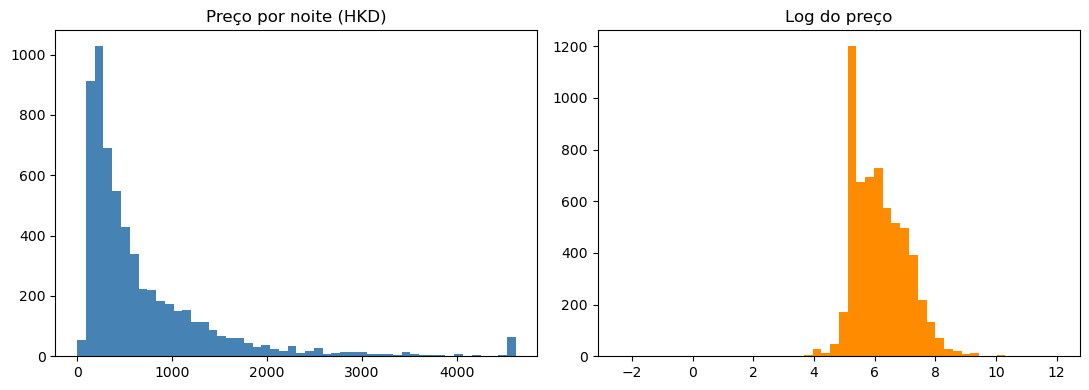

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
limite = df["price"].quantile(0.99)
ax[0].hist(df["price"].clip(upper=limite), bins=50, color="steelblue")
ax[0].set_title("Preço por noite (HKD)")
ax[1].hist(np.log(df["price"]), bins=50, color="darkorange")
ax[1].set_title("Log do preço")
plt.tight_layout()
plt.savefig("figures/preco_vs_log_preco.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
df["noites"] = (pd.to_datetime(df["price_quote_checkout_date"])
                - pd.to_datetime(df["price_quote_checkin_date"])).dt.days
df["grupo_noites"] = pd.cut(df["noites"], bins=[0, 1, 7, 27, 31, 1000],
                            labels=["1", "2-7", "8-27", "28-31", "32+"])
print(df.groupby("grupo_noites", observed=True)["price"]
        .agg(["count", "median", "mean"]).round(1))

              count  median    mean
grupo_noites                       
1              1882   545.0   982.6
2-7            1266   901.5  1267.3
8-27            227   673.9  1174.7
28-31          2535   221.3   407.1
32+             136   120.7   194.6


In [6]:
print("=== Por room_type ===")
print(df.groupby("room_type")["price"].agg(["count", "median", "mean"]).round(1))
print("\n=== Mediana por accommodates ===")
print(df.groupby("accommodates")["price"].median().round(1))

=== Por room_type ===
                 count  median    mean
room_type                             
Entire home/apt   2209   987.0  1398.2
Hotel room          15   366.0   675.1
Private room      3706   292.1   444.3
Shared room        116   225.0   287.8

=== Mediana por accommodates ===
accommodates
1      223.3
2      393.8
3      664.0
4      906.9
5     1256.0
6     1327.4
7     1348.3
8     1386.0
9     1629.4
10    1641.2
11    2187.0
12    1321.7
13    1911.8
14    3021.7
15    2569.7
16    2454.0
Name: price, dtype: float64


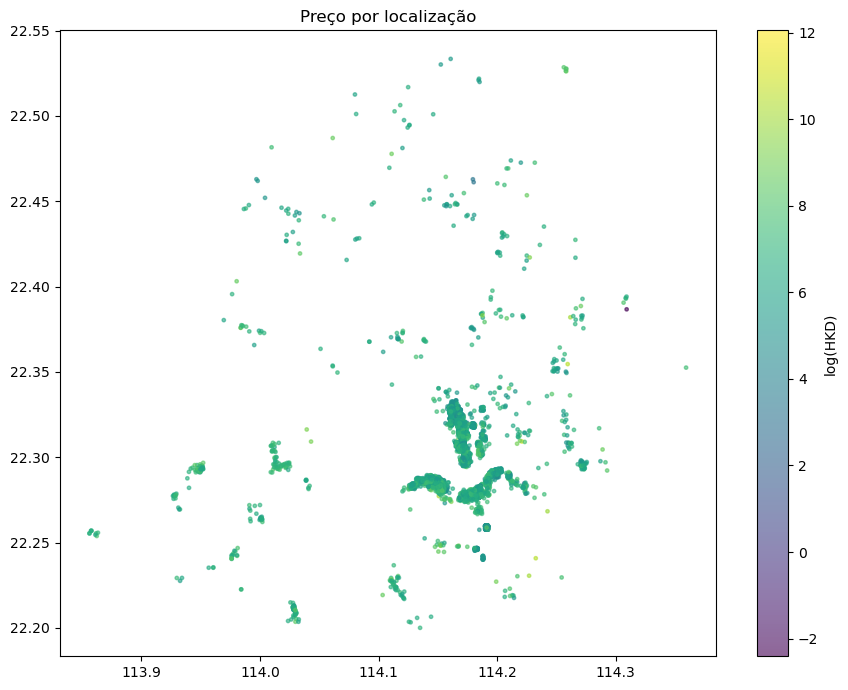

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(df["longitude"], df["latitude"],
                c=np.log(df["price"]), s=6, alpha=0.6, cmap="viridis")
plt.colorbar(sc, label="log(HKD)")
ax.set_title("Preço por localização")
plt.tight_layout()
plt.savefig("figures/mapa_precos.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
log_p = np.log(df["price"])

# IQR
q1, q3 = log_p.quantile([0.25, 0.75])
iqr = q3 - q1
out_iqr = (log_p < q1 - 1.5 * iqr) | (log_p > q3 + 1.5 * iqr)

# MAD
med = log_p.median()
mad = (log_p - med).abs().median()
z = (log_p - med).abs() / (1.4826 * mad)
out_mad = z > 3

print(f"Outliers IQR: {out_iqr.sum()}")
print(f"Outliers MAD: {out_mad.sum()}")
print(f"União:        {(out_iqr | out_mad).sum()}")

Outliers IQR: 40
Outliers MAD: 28
União:        40


In [9]:
# Correlação dos padrões de missing (só colunas com >5% missing)
cols = missing[missing > 5].index.tolist()
corr = df[cols].isna().astype(int).corr()
print("Reviews falham todas juntas? Correlação review_scores_rating vs reviews_per_month:")
print(round(corr.loc["review_scores_rating", "reviews_per_month"], 2))
print("bedrooms vs review_scores_rating:")
print(round(corr.loc["bedrooms", "review_scores_rating"], 2))

Reviews falham todas juntas? Correlação review_scores_rating vs reviews_per_month:
1.0
bedrooms vs review_scores_rating:
0.3


In [10]:
import json
df["amenities_lista"] = df["amenities"].apply(json.loads)
df["n_amenities"] = df["amenities_lista"].apply(len)

todas = [a for lista in df["amenities_lista"] for a in lista]
top15 = pd.Series(todas).value_counts().head(15)
print(f"Total de amenities distintas: {len(set(todas))}")
print("\nTop 15 amenities:")
print(top15)

Total de amenities distintas: 871

Top 15 amenities:
Wifi                5688
Air conditioning    5397
Kitchen             4071
Hot water           3427
Hangers             3367
Washer              3095
Hair dryer          3063
TV                  3045
Shampoo             2679
Elevator            2611
Iron                2593
Essentials          2501
Bed linens          2377
Smoke alarm         2259
Refrigerator        2198
Name: count, dtype: int64


## Decisões tomadas

### Alvo
- `price` convertido de texto para número. 688 linhas sem preço removidas.
- Usar `log(price)` como alvo da regressão (distribuição com cauda longa).

### Duração
- Manter todas as durações; criar `noites` e `long_stay` (noites >= 28).
- Justificação: mediana cai de 545 HKD (1 noite) para 221 HKD (28-31 noites).

### Outliers
- Dois critérios aplicados sobre log-preço: IQR e MAD.
- Três estratégias comparadas: sem tratamento, capping (limites IQR), filtragem (união IQR + MAD).

### Missing values
- Reviews (~45%): ausência com significado. Criar `tem_reviews` + imputar com mediana dos que têm.
- `bedrooms`, `bathrooms`, `beds`: valor desconhecido. Duas políticas comparadas: mediana simples vs mediana agrupada por (room_type, accommodates).
- `bathrooms_text` usado para preencher `bathrooms` antes da imputação.
- 14 colunas 100% vazias eliminadas (inclui `host_response_rate`).

### Amenities
- 871 valores distintos. Top 15 convertidas em binárias.
- `n_amenities` como feature-resumo.

### Features finais
- Numéricas: accommodates, bedrooms, bathrooms, beds, minimum_nights, noites, n_amenities, long_stay.
- Binárias: tem_reviews + top 15 amenities.
- Categóricas (one-hot): room_type, property_type, neighbourhood_cleansed.

In [13]:
from data_preparation import pipeline_completo

X_treino, Xs_outros, y_treino, ys_outros = pipeline_completo(
    estrategia_missing="simples",
    estrategia_outliers="nenhuma",
)

print("X_treino:", X_treino.shape)
print("X_val:   ", Xs_outros[0].shape)
print("X_teste: ", Xs_outros[1].shape)

X_treino: (4232, 109)
X_val:    (906, 109)
X_teste:  (908, 109)
